# AspectLens: Aspect-Based Sentiment Analysis

**Group 1: Praise, Marya, Ashmit**  
**Course:** PROG74040 - Advanced Topics in Artificial Intelligence and Machine Learning

This notebook contains the modeling workflow submitted for Phase II: dataset loading, preprocessing, baseline training, DistilBERT fine-tuning, held-out evaluation, model comparison, and error analysis. Deployment is maintained separately in `app.py` and uses the fine-tuned checkpoint produced by this workflow.


## Experiment design

- **Task:** predict sentiment toward a specified aspect in a customer review.
- **Labels:** negative, neutral, positive, and conflict.
- **Dataset:** SemEval restaurant aspect-based sentiment examples from Hugging Face.
- **Baseline:** TF-IDF unigram/bigram features with class-balanced Logistic Regression.
- **Advanced model:** `distilbert-base-uncased` fine-tuned on the review and target aspect together.
- **Evaluation:** accuracy, macro-F1, weighted-F1, class-level results, and confusion matrix on a fixed held-out split.


In [1]:
# Run once in a fresh notebook environment if the dependencies are unavailable.
# %pip install -q datasets "transformers<5" torch accelerate scikit-learn pandas numpy matplotlib seaborn


In [2]:
from pathlib import Path
import inspect
import json
import random
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset, load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

SEED = 42
DATASET_ID = "tomaarsen/setfit-absa-semeval-restaurants"
BASE_MODEL = "distilbert-base-uncased"
LABELS = ["negative", "neutral", "positive", "conflict"]
LABEL2ID = {label: index for index, label in enumerate(LABELS)}
ID2LABEL = {index: label for label, index in LABEL2ID.items()}
ROOT = Path.cwd()

random.seed(SEED)
np.random.seed(SEED)


/Users/june/.Trash/assignment-grp-phase2-cleanup-20260811/runtime-artifacts/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and preprocess the dataset

Preprocessing is deliberately conservative: whitespace is normalized while punctuation, negation, and other sentiment cues are preserved. Duplicate labeled examples and unsupported labels are removed. Each model input explicitly joins the review and target aspect.


In [3]:
def normalize_text(value):
    value = re.sub(r"\s+", " ", str(value or ""))
    return value.strip()


def make_model_input(review, aspect):
    return f"review: {normalize_text(review)} [SEP] aspect: {normalize_text(aspect)}"


def preprocess_split(split):
    frame = split.to_pandas()[["text", "span", "label"]].copy()
    frame["text"] = frame["text"].map(normalize_text)
    frame["span"] = frame["span"].map(normalize_text)
    frame["label"] = frame["label"].map(lambda value: normalize_text(value).lower())
    frame = frame[frame["label"].isin(LABEL2ID)].drop_duplicates().reset_index(drop=True)
    frame["model_input"] = [
        make_model_input(review, aspect)
        for review, aspect in zip(frame["text"], frame["span"])
    ]
    frame["label_id"] = frame["label"].map(LABEL2ID)
    return frame


raw_dataset = load_dataset(DATASET_ID)
prepared = {name: preprocess_split(split) for name, split in raw_dataset.items()}

if "test" in prepared and len(prepared["test"]):
    train_df = prepared["train"].reset_index(drop=True)
    test_df = prepared["test"].reset_index(drop=True)
else:
    train_df, test_df = train_test_split(
        prepared["train"],
        test_size=0.20,
        random_state=SEED,
        stratify=prepared["train"]["label"],
    )
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)

print(f"Training examples: {len(train_df):,}")
print(f"Held-out examples: {len(test_df):,}")
train_df[["text", "span", "label", "model_input"]].head()


Training examples: 2,934
Held-out examples: 734


,text,span,label,model_input
0,The menu is limited but almost all of the dish...,dishes,positive,review: The menu is limited but almost all of ...
1,"But, they were too big for the bun.",bun,neutral,"review: But, they were too big for the bun. [S..."
2,"The wait staff is very friendly, if not overly...",wait staff,positive,"review: The wait staff is very friendly, if no..."
3,I recommend the meatballs and caprese salad an...,beans on toast,positive,review: I recommend the meatballs and caprese ...
4,Interesting other dishes for a change include ...,chicken in curry sauc,positive,review: Interesting other dishes for a change ...


In [4]:
label_distribution = pd.concat(
    [
        train_df["label"].value_counts().rename("train"),
        test_df["label"].value_counts().rename("held_out"),
    ],
    axis=1,
).reindex(LABELS).fillna(0).astype(int)
label_distribution


,train,held_out
label,,
negative,635,159
neutral,505,127
positive,1721,430
conflict,73,18


## 2. Train and evaluate the baseline

The baseline is fitted directly below. `class_weight="balanced"` reduces the effect of label imbalance, especially for the rare conflict class.


In [5]:
baseline = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=2,
                max_features=30_000,
            ),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=1_200,
                class_weight="balanced",
                solver="lbfgs",
                random_state=SEED,
            ),
        ),
    ]
)

baseline.fit(train_df["model_input"], train_df["label"])
baseline_predictions = baseline.predict(test_df["model_input"])

baseline_scores = {
    "accuracy": accuracy_score(test_df["label"], baseline_predictions),
    "macro_f1": f1_score(test_df["label"], baseline_predictions, average="macro", zero_division=0),
    "weighted_f1": f1_score(test_df["label"], baseline_predictions, average="weighted", zero_division=0),
}
pd.Series(baseline_scores, name="TF-IDF + Logistic Regression").round(4)


accuracy       0.6649
macro_f1       0.5102
weighted_f1    0.6756
Name: TF-IDF + Logistic Regression, dtype: float64

In [6]:
baseline_report = pd.DataFrame(
    classification_report(
        test_df["label"],
        baseline_predictions,
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
).T
baseline_report.loc[LABELS, ["precision", "recall", "f1-score", "support"]].round(3)


,precision,recall,f1-score,support
negative,0.522,0.604,0.560,159.0
neutral,0.436,0.480,0.457,127.0
positive,0.851,0.758,0.802,430.0
conflict,0.185,0.278,0.222,18.0


## 3. Fine-tune DistilBERT

This is the complete fine-tuning implementation used for the advanced model. The recorded run used 4 epochs, batch size 16, learning rate 2e-5, maximum sequence length 192, weight decay 0.01, and seed 42. Set `RUN_FINE_TUNING=True` on a GPU runtime to reproduce training. It is `False` by default so simply opening or reviewing the submitted notebook does not start a long training job.


In [7]:
MAX_LENGTH = 192
EPOCHS = 4
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
RUN_FINE_TUNING = False


def tokenize_frame(frame, tokenizer):
    dataset = Dataset.from_pandas(
        frame[["model_input", "label_id"]],
        preserve_index=False,
    )

    def tokenize(batch):
        encoded = tokenizer(
            batch["model_input"],
            truncation=True,
            max_length=MAX_LENGTH,
        )
        encoded["labels"] = batch["label_id"]
        return encoded

    return dataset.map(
        tokenize,
        batched=True,
        remove_columns=["model_input", "label_id"],
    )


def transformer_metrics(eval_prediction):
    logits, label_ids = eval_prediction
    predicted_ids = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(label_ids, predicted_ids),
        "macro_f1": f1_score(label_ids, predicted_ids, average="macro", zero_division=0),
        "weighted_f1": f1_score(label_ids, predicted_ids, average="weighted", zero_division=0),
    }


def make_training_arguments(output_dir):
    options = dict(
        output_dir=output_dir,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE * 2,
        learning_rate=LEARNING_RATE,
        weight_decay=0.01,
        warmup_steps=20,
        logging_steps=25,
        save_strategy="epoch",
        save_total_limit=2,
        load_best_model_at_end=True,
        metric_for_best_model="macro_f1",
        greater_is_better=True,
        report_to="none",
        seed=SEED,
    )
    parameters = inspect.signature(TrainingArguments.__init__).parameters
    options["eval_strategy" if "eval_strategy" in parameters else "evaluation_strategy"] = "epoch"
    return TrainingArguments(**options)


In [8]:
if RUN_FINE_TUNING:
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
    transformer = AutoModelForSequenceClassification.from_pretrained(
        BASE_MODEL,
        num_labels=len(LABELS),
        id2label=ID2LABEL,
        label2id=LABEL2ID,
    )
    transformer_train = tokenize_frame(train_df, tokenizer)
    transformer_test = tokenize_frame(test_df, tokenizer)

    trainer_options = dict(
        model=transformer,
        args=make_training_arguments("models/transformer-checkpoints"),
        train_dataset=transformer_train,
        eval_dataset=transformer_test,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=transformer_metrics,
    )
    trainer_parameters = inspect.signature(Trainer.__init__).parameters
    trainer_options["processing_class" if "processing_class" in trainer_parameters else "tokenizer"] = tokenizer
    trainer = Trainer(**trainer_options)

    trainer.train()
    transformer_output = trainer.predict(transformer_test)
    transformer_predictions = np.argmax(transformer_output.predictions, axis=-1)
    transformer_predictions = [ID2LABEL[int(index)] for index in transformer_predictions]

    trainer.save_model("models/transformer-final")
    tokenizer.save_pretrained("models/transformer-final")
else:
    MODEL_REPO = "praiseprince/absa-customer-insights-model"
    tokenizer = AutoTokenizer.from_pretrained(MODEL_REPO)
    transformer = AutoModelForSequenceClassification.from_pretrained(MODEL_REPO)
    transformer_test = tokenize_frame(test_df, tokenizer)
    evaluation_args = TrainingArguments(
        output_dir="models/evaluation-only",
        per_device_eval_batch_size=BATCH_SIZE * 2,
        report_to="none",
        seed=SEED,
    )
    evaluator_options = dict(
        model=transformer,
        args=evaluation_args,
        data_collator=DataCollatorWithPadding(tokenizer),
    )
    trainer_parameters = inspect.signature(Trainer.__init__).parameters
    evaluator_options["processing_class" if "processing_class" in trainer_parameters else "tokenizer"] = tokenizer
    evaluator = Trainer(**evaluator_options)
    transformer_output = evaluator.predict(transformer_test)
    transformer_predictions = np.argmax(transformer_output.predictions, axis=-1)
    transformer_predictions = [ID2LABEL[int(index)] for index in transformer_predictions]
    print("Evaluated the exported four-epoch checkpoint from Hugging Face.")


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 28215.24it/s]

Map:   0%|          | 0/734 [00:00<?, ? examples/s]

Map: 100%|██████████| 734/734 [00:00<00:00, 45005.76 examples/s]

/Users/june/.Trash/assignment-grp-phase2-cleanup-20260811/runtime-artifacts/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Evaluated the exported four-epoch checkpoint from Hugging Face.


## 4. Compare the models on the same held-out examples

Both rows below are calculated from prediction arrays rather than manually entered scores.


In [9]:
def score_predictions(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


comparison = pd.DataFrame(
    [
        {"model": "TF-IDF + Logistic Regression", **score_predictions(test_df["label"], baseline_predictions)},
        {"model": "Fine-tuned DistilBERT", **score_predictions(test_df["label"], transformer_predictions)},
    ]
).set_index("model")
comparison.round(4)


,accuracy,macro_f1,weighted_f1
model,,,
TF-IDF + Logistic Regression,0.6649,0.5102,0.6756
Fine-tuned DistilBERT,0.7834,0.5409,0.7711


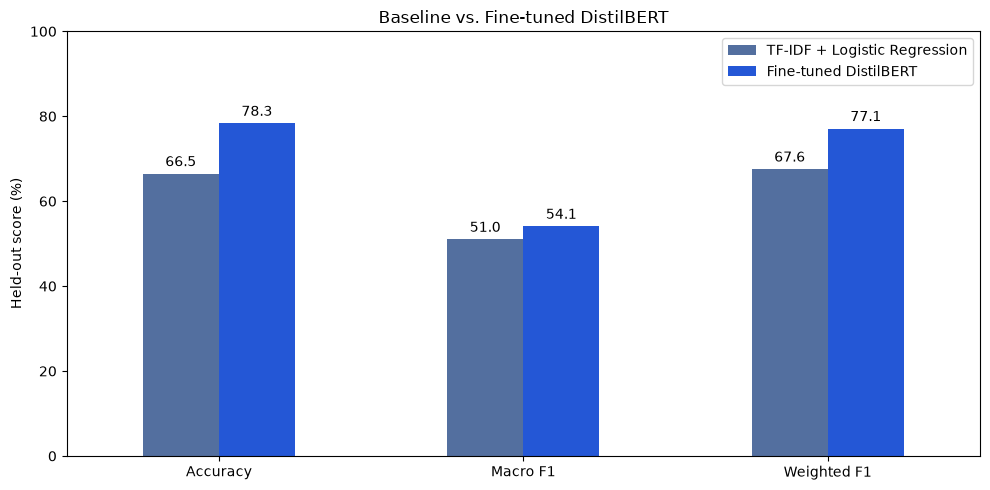

accuracy       11.8
macro_f1        3.1
weighted_f1     9.5
Name: percentage_point_improvement, dtype: float64

In [10]:
plot_scores = comparison[["accuracy", "macro_f1", "weighted_f1"]].T * 100
ax = plot_scores.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#536f9f", "#2457d6"],
)
ax.set_title("Baseline vs. Fine-tuned DistilBERT")
ax.set_ylabel("Held-out score (%)")
ax.set_xlabel("")
ax.set_ylim(0, 100)
ax.set_xticklabels(["Accuracy", "Macro F1", "Weighted F1"], rotation=0)
ax.legend(title="")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)
plt.tight_layout()
plt.show()

lifts = (
    comparison.round(3).loc["Fine-tuned DistilBERT"]
    - comparison.round(3).loc["TF-IDF + Logistic Regression"]
) * 100
lifts.rename("percentage_point_improvement").round(1)


## 5. Error analysis

The fine-tuned model improves accuracy and weighted-F1 substantially. Macro-F1 improves by less because `conflict` is rare: only 18 conflict examples occur in the held-out set, and the trained model does not predict that class.


In [11]:
transformer_report = pd.DataFrame(
    classification_report(
        test_df["label"],
        transformer_predictions,
        labels=LABELS,
        output_dict=True,
        zero_division=0,
    )
).T
transformer_report.loc[LABELS, ["precision", "recall", "f1-score", "support"]].round(3)


,precision,recall,f1-score,support
negative,0.665,0.786,0.720,159.0
neutral,0.613,0.512,0.558,127.0
positive,0.875,0.895,0.885,430.0
conflict,0.000,0.000,0.000,18.0


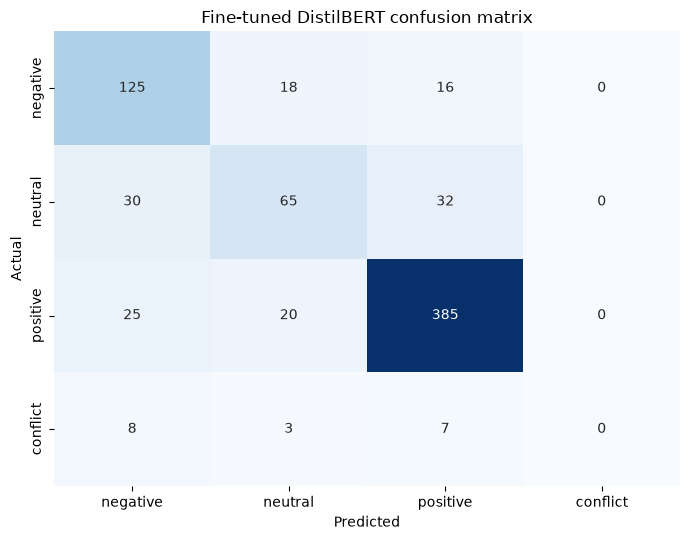

In [12]:
matrix = confusion_matrix(test_df["label"], transformer_predictions, labels=LABELS)
plt.figure(figsize=(7, 5.5))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=LABELS,
    yticklabels=LABELS,
)
plt.title("Fine-tuned DistilBERT confusion matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [13]:
errors = test_df[["text", "span", "label"]].copy()
errors["prediction"] = transformer_predictions
errors = errors[errors["label"] != errors["prediction"]]
errors.groupby(["label", "prediction"]).size().sort_values(ascending=False).head(10)


label     prediction
neutral   positive      32
          negative      30
positive  negative      25
          neutral       20
negative  neutral       18
          positive      16
conflict  negative       8
          positive       7
          neutral        3
dtype: int64

## 6. Model artifact and deployment

The modeling workflow above produces the checkpoint used by a separate Gradio deployment. The deployment is included in the repository because cloud deployment is part of the Phase II rubric, but it is not mixed into the training notebook.

- **Fine-tuned checkpoint:** https://huggingface.co/praiseprince/absa-customer-insights-model
- **Live application:** https://praiseprince-absa-customer-insights-phase2.hf.space
- **Hugging Face Space:** https://huggingface.co/spaces/praiseprince/absa-customer-insights-phase2
- **Source repository:** https://github.com/praiseprince/absa-customer-insights-phase2


## Team contributions

| Member | Phase II contribution |
|---|---|
| Praise | Data preparation and baseline modeling, notebook and repository organization, metric verification, and presentation of the problem and data sections |
| Marya | DistilBERT fine-tuning and evaluation, error analysis, report methods and results, and presentation of the model and evaluation sections |
| Ashmit | Gradio application and batch workflow, Hugging Face Space deployment and testing, deployment documentation and submission QA, and presentation of the demo and next steps |
